<!-- reader-content -->

# Spectra and parameter sweeps

Track an avoided crossing, inspect its dressed-state assignments, and compare
a fluxonium model with published spectroscopy and readout data.

quchip uses GHz for frequencies and couplings.

## Declare the coupled model

Sweep one transmon through the other. Their bus-mediated interaction produces
an avoided crossing; use `RWA()` in a rotating frame for this study.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np

from quchip import RWA, Capacitive, ChargeDrive, Chip, DuffingTransmon, Resonator, SpectrumSweep, Sweep

q1_frequency = 5.30
q2_frequency0 = 5.58
bus_frequency = 6.55
q2_frequencies = np.linspace(5.255, 5.345, 181)
coupling_strength = 0.050

q1 = DuffingTransmon(
    freq=q1_frequency,
    anharmonicity=-0.65,
    levels=4,
    label="q1",
)
q2 = DuffingTransmon(
    freq=q2_frequency0,
    anharmonicity=-0.65,
    levels=4,
    label="q2",
)
bus = Resonator(freq=bus_frequency, levels=4, label="bus")

chip = Chip(
    [q1, q2, bus],
    couplings=[
        Capacitive(q1, bus, g=coupling_strength, label="q1-bus"),
        Capacitive(q2, bus, g=coupling_strength, label="q2-bus"),
    ],
    frame="rotating",
    approximation=RWA(),
)

## Sweep the avoided crossing

`Sweep` names the public parameter path to vary. `SpectrumSweep` creates an
isolated chip at each point, so the original declaration remains unchanged.
Setting `overlap_threshold=0.0` keeps both intentionally hybridized
one-excitation labels available at the centre of the avoided crossing.

In [2]:
frequency_axis = Sweep(q2_frequencies, name="q2.freq")
sweep_result = SpectrumSweep(
    chip,
    [frequency_axis],
    evals_count=4,
    overlap_threshold=0.0,
).run(progress=False)

Subtract the ground energy from the two qubit-like branches. The bus-like
excitation stays above this frequency window.

In [3]:
ground_energy = sweep_result.eigenvalues[:, 0]
qubit_branches = sweep_result.eigenvalues[:, 1:3] - ground_energy[:, None]
lower_branch = qubit_branches[:, 0]
upper_branch = qubit_branches[:, 1]
splitting = upper_branch - lower_branch
q1_branch = sweep_result.dressed_index(q1=1, q2=0, bus=0).astype(int) - 1

minimum_index = int(np.argmin(splitting))
minimum_splitting = float(splitting[minimum_index])
minimum_frequency = float(q2_frequencies[minimum_index])
inferred_exchange_rate = 0.5 * minimum_splitting

q1_assignment = sweep_result.dressed_index(q1=1, q2=0, bus=0)
q1_label = (1, 0, 0)
q1_label_position = sweep_result.bare_labels.index(q1_label)
q1_assignment_overlap = np.asarray(
    sweep_result.assignment_overlaps[..., q1_label_position]
)

<details>
<summary>Plotting code</summary>

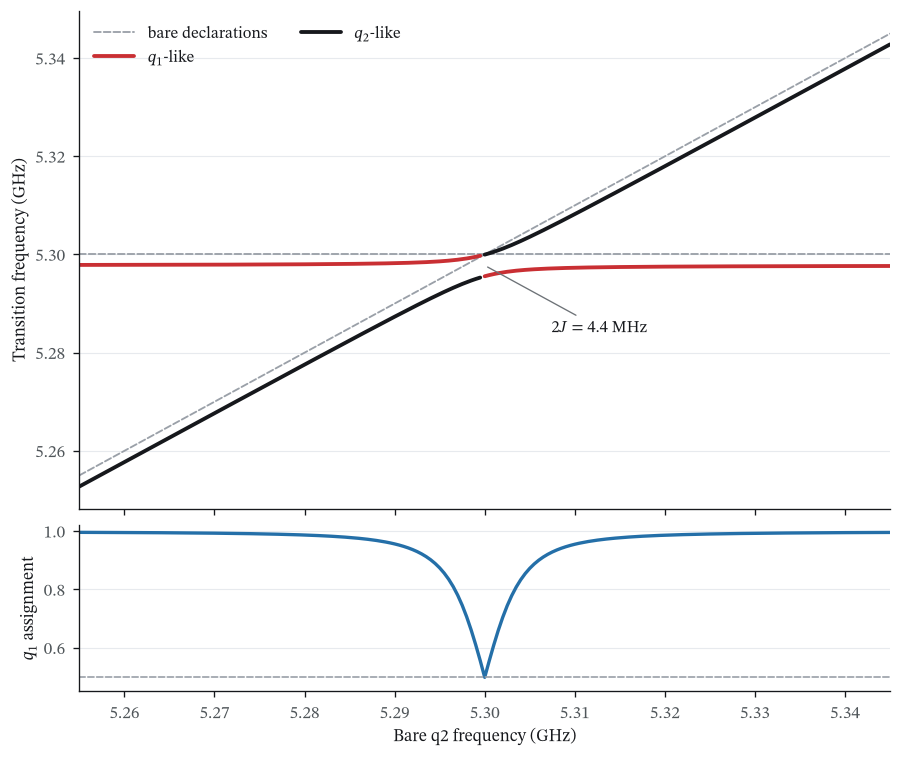

In [4]:
import shutil

plt.style.use("../docs/_static/quchip.mplstyle")
plt.rcParams["text.usetex"] = bool(shutil.which("latex"))

figure, (axis, overlap_axis) = plt.subplots(
    2,
    1,
    figsize=(7.4, 6.2),
    height_ratios=(3.0, 1.0),
    sharex=True,
    layout="constrained",
)

axis.plot(q2_frequencies, q2_frequencies, color="#9AA0A8", linestyle="--", linewidth=1.1)
axis.axhline(q1_frequency, color="#9AA0A8", linestyle="--", linewidth=1.1, label="bare declarations")
for branch_index in (0, 1):
    q1_like = q1_branch == branch_index
    axis.plot(
        q2_frequencies,
        np.where(q1_like, qubit_branches[:, branch_index], np.nan),
        color="#C92F33",
        linewidth=2.3,
        label="$q_1$-like" if branch_index == 0 else None,
    )
    axis.plot(
        q2_frequencies,
        np.where(~q1_like, qubit_branches[:, branch_index], np.nan),
        color="#16181C",
        linewidth=2.3,
        label="$q_2$-like" if branch_index == 0 else None,
    )
axis.annotate(
    f"$2J$ = {1.0e3 * minimum_splitting:.1f} MHz",
    xy=(minimum_frequency, 0.5 * (lower_branch[minimum_index] + upper_branch[minimum_index])),
    xytext=(40, -40),
    textcoords="offset points",
    arrowprops={"arrowstyle": "-", "color": "#6D7277", "linewidth": 0.8},
    fontsize=10,
)
axis.set(
    ylabel="Transition frequency (GHz)",
    xlim=(q2_frequencies[0], q2_frequencies[-1]),
)
axis.legend(frameon=False, ncols=2, loc="upper left")

overlap_axis.plot(
    q2_frequencies,
    q1_assignment_overlap,
    color="#246FA8",
    linewidth=2.0,
)
overlap_axis.axhline(0.5, color="#9AA0A8", linestyle="--", linewidth=1.0)
overlap_axis.set(
    xlabel="Bare q2 frequency (GHz)",
    ylabel=r"$q_1$ assignment",
    ylim=(0.45, 1.02),
)

figure_path = "../docs/images/resolve_and_sweep.svg"
figure.savefig(figure_path)
plt.show()

</details>

```{figure} ../images/resolve_and_sweep.svg
:width: 720px
:alt: Dressed transmon avoided crossing with the q1 bare-state assignment weight below

The bare declarations cross while the dressed transitions retain a finite
splitting. The assignment weight exposes the hybridized region directly.
```

The dashed lines are the bare declarations. Red follows the more $q_1$-like
dressed transition, and black follows the more $q_2$-like transition. At the
crossing, the branches remain separated by $2J\approx4.4$ MHz. Second-order
dispersive perturbation theory gives $4.0$ MHz. The resolved spectrum includes
the higher-order dressing retained by this truncated model. The lower panel
shows why a bare-state label needs care at the crossing: its assignment weight
falls to about one half as the two excitations hybridize.

## Inspect the model after the sweep

The declared frequencies are inputs. `chip.freq()` returns dressed
$0\rightarrow1$ transitions, while `chip.static_zz()` returns the conditional
two-qubit shift for this coupled model.

In [5]:
q1_line = ChargeDrive(q1, label="q1-charge")
_ = chip.wire(q1_line)

initial_dressed_frequencies = {
    "q1": float(chip.freq(q1)),
    "q2": float(chip.freq(q2)),
    "bus": float(chip.freq(bus)),
}
initial_static_zz = float(chip.static_zz(q1, q2))
kerr = chip.kerr_matrix()

assert np.isclose(kerr[q1, q1], chip.dressed_anharmonicity(q1))
assert np.isclose(kerr[q1, bus], chip.dispersive_shift(q1, bus))

static_snapshot = {
    "q1_f01_ghz": float(chip.freq(q1)),
    "q1_f12_ghz": float(chip.transition_frequency(q1, 1, 2)),
    "kerr_labels": kerr.labels,
    "kerr_matrix_ghz": np.asarray(kerr.values),
    "q1_drive_matrix_element": complex(
        chip.drive_matrix_elements(q1, drives=[q1_line])[q1_line]
    ),
}

static_snapshot

{'q1_f01_ghz': 5.297749744925113,
 'q1_f12_ghz': 4.64911449272806,
 'kerr_labels': ('q1', 'q2', 'bus'),
 'kerr_matrix_ghz': array([[-6.48635252e-01,  2.26043091e-05, -1.37823836e-03],
        [ 2.26043091e-05, -6.48041520e-01, -2.06691858e-03],
        [-1.37823836e-03, -2.06691858e-03, -4.50706699e-06]]),
 'q1_drive_matrix_element': -0.9989561107920195j}

`kerr_matrix()` gathers the dressed anharmonicities on its diagonal and the
full-pull cross-Kerr shifts off diagonal, in `chip.devices` order. The two
assertions above check its entries against the scalar APIs.

The resolved Hamiltonian applies the chip's basis, frame, and approximation
strategy through the same public path used for simulation.

In [6]:
chip.hamiltonian()

PhysicsExpr(kind='add', args=(PhysicsExpr(kind='add', args=(PhysicsExpr(kind='add', args=(PhysicsExpr(kind='add', args=(PhysicsExpr(kind='scale', args=(PhysicsExpr(kind='literal', args=(1.0,), labels=()), PhysicsExpr(kind='matrix', args=(array([[ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j, -0.00414144+0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j, -0.00828288+0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       ...,
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
        -3.88907067+0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         0.        +0.j, -3.89321211+0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j, -3.89735355+0.j]],
     

`chip.resolve().dropped_terms_summary()` audits the RWA without reconstructing
the Hamiltonian by hand:

In [7]:
rwa_summary = chip.resolve().dropped_terms_summary()
print(rwa_summary)

4 term(s) dropped:
  [q1-bus] coupling band (Δa=-1, Δb=-1) on q1·bus  (counter-rotating under RWA; amp 0.15 GHz, freq 11.8519 GHz)
  [q1-bus] coupling band (Δa=+1, Δb=+1) on q1·bus  (counter-rotating under RWA; amp 0.15 GHz, freq 11.8519 GHz)
  [q2-bus] coupling band (Δa=-1, Δb=-1) on q2·bus  (counter-rotating under RWA; amp 0.15 GHz, freq 12.1314 GHz)
  [q2-bus] coupling band (Δa=+1, Δb=+1) on q2·bus  (counter-rotating under RWA; amp 0.15 GHz, freq 12.1314 GHz)


<details>
<summary>Numerical checks and record</summary>

In [8]:
second_order_splitting_scale = 2.0 * coupling_strength**2 / abs(bus_frequency - q1_frequency)
relative_difference_to_second_order = (
    abs(minimum_splitting - second_order_splitting_scale) / minimum_splitting
)

if minimum_index in (0, len(q2_frequencies) - 1):
    raise RuntimeError("The avoided-crossing minimum lies at the sweep boundary.")
if not 4.3e-3 < minimum_splitting < 4.5e-3:
    raise RuntimeError("The resolved splitting does not reproduce the slide-scale exchange rate.")
if len(chip.resolve().dropped_terms) != 4:
    raise RuntimeError("The RWA ledger does not contain the four counter-rotating coupling bands.")
if chip.parameters["q2.freq"] != q2_frequency0:
    raise RuntimeError("SpectrumSweep mutated the original chip.")

statics_receipt = {
    "approximation": chip.settings["approximation"],
    "dressed_frequencies_ghz": initial_dressed_frequencies,
    "dropped_rwa_terms": len(chip.resolve().dropped_terms),
    "figure": figure_path,
    "full_dimension": int(np.prod(chip.dims)),
    "inferred_exchange_rate_mhz": 1.0e3 * inferred_exchange_rate,
    "minimum_at_bare_q2_ghz": minimum_frequency,
    "minimum_splitting_mhz": 1.0e3 * minimum_splitting,
    "original_chip_unchanged": bool(chip.parameters["q2.freq"] == q2_frequency0),
    "relative_difference_to_second_order": relative_difference_to_second_order,
    "second_order_splitting_scale_mhz": 1.0e3 * second_order_splitting_scale,
    "static_zz_khz": 1.0e6 * initial_static_zz,
    "sweep_points": len(q2_frequencies),
}

print(f"RESULT statics={json.dumps(statics_receipt, sort_keys=True, separators=(',', ':'))}")

RESULT statics={"approximation":"RWA","dressed_frequencies_ghz":{"bus":6.55414143998032,"q1":5.297749744925113,"q2":5.577226664394395},"dropped_rwa_terms":4,"figure":"../docs/images/resolve_and_sweep.svg","full_dimension":64,"inferred_exchange_rate_mhz":2.204908100780223,"minimum_at_bare_q2_ghz":5.3,"minimum_splitting_mhz":4.409816201560446,"original_chip_unchanged":true,"relative_difference_to_second_order":0.09293271710857891,"second_order_splitting_scale_mhz":4.000000000000001,"static_zz_khz":22.604309073415152,"sweep_points":181}


</details>

## Change one design parameter

`with_params()` changes one bare frequency while preserving the source chip.

In [9]:
shifted_chip = chip.with_params({"q2.freq": 5.40})

{
    "original_q2_freq": chip.parameters["q2.freq"],
    "shifted_q2_freq": shifted_chip.parameters["q2.freq"],
    "shifted_dressed_q2_freq": float(shifted_chip.freq("q2")),
}

{'original_q2_freq': 5.58,
 'shifted_q2_freq': 5.4,
 'shifted_dressed_q2_freq': 5.39765272276005}

## Independent and linked parameter studies

`Sweep.expand()` shows the parameter dictionaries before any calculation runs.
Independent axes form a Cartesian grid. `Sweep.zip()` pairs values when the
parameters must move together.

In [10]:
frequency_values = Sweep([5.28, 5.30, 5.32], name="q2.freq")
coupling_values = Sweep([0.045, 0.050], name="q1-bus.g")
independent_points = Sweep.expand([frequency_values, coupling_values])

linked_points = Sweep.expand(
    [
        Sweep.zip(
            Sweep([5.28, 5.30, 5.32], name="q2.freq"),
            Sweep([0.045, 0.050, 0.055], name="q1-bus.g"),
        )
    ]
)

{
    "independent_point_count": len(independent_points),
    "first_independent_point": independent_points[0],
    "linked_point_count": len(linked_points),
    "last_linked_point": linked_points[-1],
}

{'independent_point_count': 6,
 'first_independent_point': {'q2.freq': np.float64(5.28),
  'q1-bus.g': np.float64(0.045)},
 'linked_point_count': 3,
 'last_linked_point': {'q2.freq': np.float64(5.32),
  'q1-bus.g': np.float64(0.055)}}

Pass either axis list to `SpectrumSweep` when every point needs a dressed
spectrum. Use `with_params()` directly when only a few points or a custom
observable are needed.

## Check labels before interpreting branches

Near an avoided crossing, a dressed eigenstate can be shared between several
bare product states. `dressed_index()` tracks the assigned branch across the
sweep, while `assignment_overlaps` records the squared overlap with the assigned bare state.
For one chip, `state_components()` exposes the largest bare-basis weights.

In [11]:
q1_components = chip.state_components({q1: 1}, n_components=4)

{
    "tracked_grid_shape": q1_assignment.shape,
    "lowest_q1_assignment_overlap": float(np.nanmin(q1_assignment_overlap)),
    "q1_like_state_components": q1_components,
}

{'tracked_grid_shape': (181,),
 'lowest_q1_assignment_overlap': 0.49837736639905067,
 'q1_like_state_components': {(1, 0, 0): 0.9982630319848723,
  (0, 0, 1): 0.0016179267171988069,
  (0, 1, 0): 6.181316921618551e-05,
  (2, 0, 1): 3.98212745963501e-05}}

At the crossing, each dressed branch contains roughly equal bare qubit
weights. Lowering `overlap_threshold` retains these labels without improving
their physical assignment.

## Check numerical resolution

The sweep grid locates the minimum; device `levels` control Hilbert-space
truncation. They are separate convergence questions. Here the 181-point grid
and its every-other-point subset agree because both contain the symmetry point.

In [12]:
fine_minimum = float(np.min(splitting))
coarse_minimum = float(np.min(splitting[::2]))

{
    "fine_grid_points": len(splitting),
    "coarse_grid_points": len(splitting[::2]),
    "minimum_difference_hz": 1.0e9 * abs(fine_minimum - coarse_minimum),
}

{'fine_grid_points': 181,
 'coarse_grid_points': 91,
 'minimum_difference_hz': 0.0}

Check local-level convergence separately for the reported transition, matrix
element, or dispersive shift.

## Paper example: experimental fluxonium spectroscopy

Stefanski *et al.* measured a fluxonium and its readout resonator while
sweeping external flux. Their paper,
[*Improved fluxonium readout through dynamic flux
pulsing*](https://arxiv.org/abs/2411.13437), reports the fitted circuit
parameters and the operating points used for readout. The authors also publish
their
[analysis and modelling code](https://github.com/AndersenQubitLab/FPA-RO-experimental)
and the [measurement archive](https://doi.org/10.4121/1092cb12-9198-4d43-8500-401c78a5dc15).

We first reproduce the qubit spectrum with one `Fluxonium`. The readout
resonator is added afterward.

### Load the published measurements

`processed_data_fx8.csv` contains measured qubit frequencies and the authors'
fitted parameters. `res_fit_results.csv` contains the conditional resonator
frequencies and their half-difference $\chi=(f_{r,1}-f_{r,0})/2$.

In [13]:
import csv
import io
from urllib.request import urlopen

from quchip import CouplingModel, Fluxonium, Scalar, parameter

paper_data_root = (
    "https://raw.githubusercontent.com/AndersenQubitLab/"
    "FPA-RO-experimental/57dc268dd048d1372db082c3ddd97a04871580bf"
)


def published_rows(filename):
    url = f"{paper_data_root}/{filename}"
    with urlopen(url) as response:  # noqa: S310 - fixed public research archive
        return list(csv.DictReader(io.StringIO(response.read().decode("utf-8"))))


spectrum_rows = published_rows("processed_data_fx8.csv")
readout_rows = published_rows("res_fit_results.csv")

fitted_values = np.asarray(
    [float(spectrum_rows[index]["energy_params"]) for index in range(5)]
)
resonator_frequency, readout_coupling, paper_E_J, paper_E_C, paper_E_L = fitted_values

paper_parameters = {
    "E_J_ghz": paper_E_J,
    "E_C_ghz": paper_E_C,
    "E_L_ghz": paper_E_L,
    "resonator_frequency_ghz": resonator_frequency,
    "readout_coupling_ghz": readout_coupling,
}

paper_parameters

{'E_J_ghz': np.float64(3.8217399868188027),
 'E_C_ghz': np.float64(0.8652719648666846),
 'E_L_ghz': np.float64(0.8215798519627777),
 'resonator_frequency_ghz': np.float64(5.175140901166961),
 'readout_coupling_ghz': np.float64(0.037156311892102264)}

### Reproduce the qubit spectrum

Figure 2 of the paper covers $0.5\leq\Phi_{\mathrm{ext}}/\Phi_0\leq0.85$.
The model curve uses 351 evenly spaced flux values, more than twice the
measurement density. Residuals are evaluated by interpolating that independent
curve at the measured coordinates. quchip receives the authors' fitted
energies unchanged.

In [14]:
paper_flux_all = np.asarray(
    [float(row["phi_ext_qubit"]) for row in spectrum_rows if row["phi_ext_qubit"]]
)
measured_f01_all = np.asarray(
    [float(row["qubit_freq"]) for row in spectrum_rows if row["qubit_freq"]]
)
figure_2_window = paper_flux_all <= 0.85
paper_flux = paper_flux_all[figure_2_window]
measured_f01 = measured_f01_all[figure_2_window]


def isolated_f01(phi_ext):
    q = Fluxonium(
        E_C=paper_E_C,
        E_J=paper_E_J,
        E_L=paper_E_L,
        phi_ext=phi_ext,
        levels=4,
        num_basis=300,
        phi_max=5.0 * np.pi,
        basis="eigen",
        label="q",
    )
    return float(q.freq)


Evaluate the spectrum on its own flux grid and compare it with the measured points.

In [15]:
paper_model_flux = np.linspace(0.5, 0.85, 351)
predicted_f01_grid = np.asarray([isolated_f01(phi) for phi in paper_model_flux])
predicted_f01_at_data = np.interp(paper_flux, paper_model_flux, predicted_f01_grid)
f01_residual_mhz = 1.0e3 * (predicted_f01_at_data - measured_f01)

<details>
<summary>Plotting code</summary>

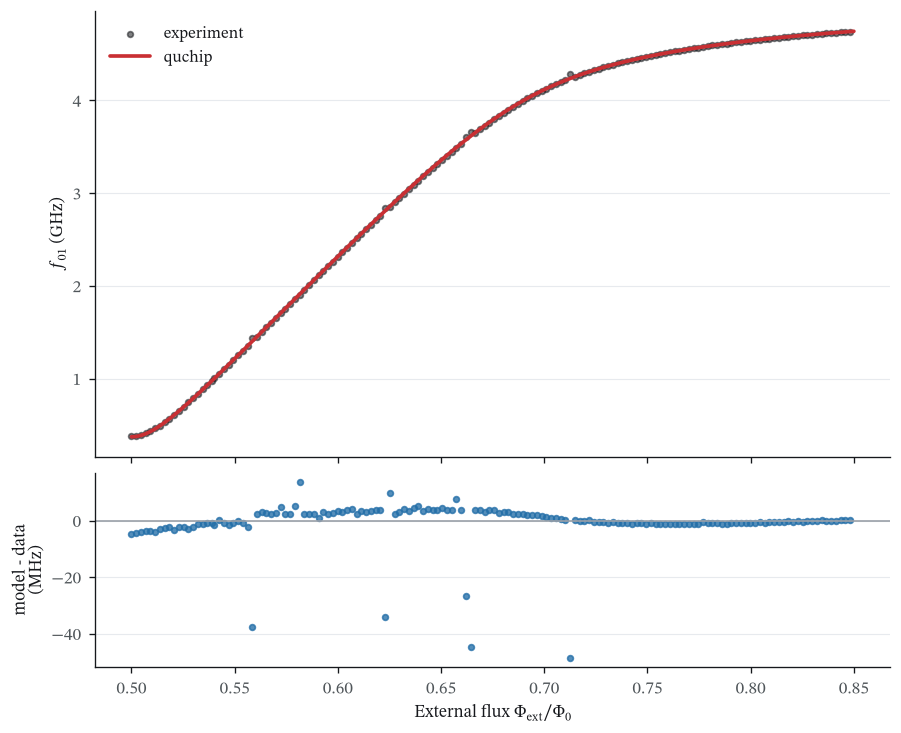

In [16]:
paper_spectrum_figure, (spectrum_axis, residual_axis) = plt.subplots(
    2,
    1,
    figsize=(7.4, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [2.3, 1.0]},
    layout="constrained",
)
spectrum_axis.scatter(
    paper_flux,
    measured_f01,
    s=12,
    color="#16181C",
    alpha=0.55,
    label="experiment",
)
spectrum_axis.plot(
    paper_model_flux,
    predicted_f01_grid,
    color="#C92F33",
    linewidth=2.2,
    label="quchip",
)
spectrum_axis.set_ylabel(r"$f_{01}$ (GHz)")
spectrum_axis.legend()

residual_axis.axhline(0.0, color="#9AA0A8", linewidth=1.0)
residual_axis.scatter(paper_flux, f01_residual_mhz, s=12, color="#246FA8", alpha=0.78)
residual_axis.set(
    xlabel=r"External flux $\Phi_{\mathrm{ext}}/\Phi_0$",
    ylabel="model - data\n(MHz)",
)

paper_spectrum_path = "../docs/images/stefanski_fluxonium_spectrum.svg"
paper_spectrum_figure.savefig(paper_spectrum_path)
plt.show()

</details>

```{figure} ../images/stefanski_fluxonium_spectrum.svg
:width: 720px
:alt: Measured fluxonium transition frequencies, quchip prediction, and pointwise residuals across external flux

The authors' fitted fluxonium energies reproduce the measured frequency curve.
Every extracted point in the paper's Figure 2 window is shown.
```

In [17]:
spectrum_check = {
    "measurement_points": len(measured_f01),
    "median_absolute_error_mhz": float(np.median(np.abs(f01_residual_mhz))),
    "p95_absolute_error_mhz": float(np.quantile(np.abs(f01_residual_mhz), 0.95)),
    "rmse_mhz": float(np.sqrt(np.mean(f01_residual_mhz**2))),
    "points_above_10_mhz": int(np.count_nonzero(np.abs(f01_residual_mhz) > 10.0)),
}
spectrum_check

{'measurement_points': 153,
 'median_absolute_error_mhz': 1.5923938298039175,
 'p95_absolute_error_mhz': 6.076768528398682,
 'rmse_mhz': 7.573880277392135,
 'points_above_10_mhz': 6}

The six residuals above 10 MHz remain in the plot and in the RMSE. The median
and 95th percentile describe the rest of the curve without deleting those
points.

### Add the readout resonator

The released model couples a resonator to the fluxonium oscillator coordinate
$c$ through $g(ca^\dagger+c^\dagger a)$. `CouplingModel` is quchip's public
extension point for declaring that interaction without changing the device
models.

In [18]:
class FluxoniumReadoutCoupling(CouplingModel):
    """Exchange interaction used in the authors' released readout model."""

    g: Scalar = parameter(unit="GHz")
    oscillator_length: Scalar = parameter(positive=True)

    def interaction(self, q, r, p):
        scale = np.sqrt(2.0)
        lowering = q.phi * (1.0 / (p.oscillator_length * scale)) + (
            1j * p.oscillator_length / scale
        ) * q.charge
        raising = q.phi * (1.0 / (p.oscillator_length * scale)) - (
            1j * p.oscillator_length / scale
        ) * q.charge
        return p.g * (lowering * r.adag + raising * r.a)


Use the published interaction with the fitted circuit parameters.

In [19]:
paper_q = Fluxonium(
    E_C=paper_E_C,
    E_J=paper_E_J,
    E_L=paper_E_L,
    phi_ext=0.5,
    levels=10,
    num_basis=300,
    phi_max=5.0 * np.pi,
    basis="eigen",
    label="q",
)
paper_readout = Resonator(freq=resonator_frequency, levels=3, label="readout")
paper_edge = FluxoniumReadoutCoupling(
    paper_q,
    paper_readout,
    g=readout_coupling,
    oscillator_length=(8.0 * paper_E_C / paper_E_L) ** 0.25,
    label="q-readout",
)

paper_chip = Chip(
    [paper_q, paper_readout],
    [paper_edge],
    basis="eigen",
    frame="lab",
)

`chip.freq("readout")` is the resonator transition with the qubit in
$|0\rangle$. `chip.dispersive_shift()` returns the full state-dependent pull,
so the paper's $\chi$ is half of it.

In [20]:
readout_rows = [row for row in readout_rows if row["phi_ext_disshift"]]
readout_flux_all = np.asarray([float(row["phi_ext_disshift"]) for row in readout_rows])
measured_fr0_all = np.asarray([float(row["fr_q0"]) for row in readout_rows])
measured_fr1_all = np.asarray([float(row["fr_q1"]) for row in readout_rows])
measured_chi_all = np.asarray([float(row["chi"]) for row in readout_rows])

readout_window = readout_flux_all <= 0.85
readout_flux = readout_flux_all[readout_window]
measured_fr0 = measured_fr0_all[readout_window]
measured_fr1 = measured_fr1_all[readout_window]
measured_chi_mhz = measured_chi_all[readout_window]


At each flux, ask the same chip for the two conditional readout frequencies.

In [21]:
def readout_observables(phi_ext):
    point = paper_chip.with_params({"q.phi_ext": phi_ext})
    fr0 = float(point.freq("readout"))
    full_pull = float(point.dispersive_shift("q", "readout"))
    return fr0, fr0 + full_pull, 500.0 * full_pull


readout_model_flux = np.linspace(0.5, 0.85, 351)
predicted_readout_grid = np.asarray(
    [readout_observables(phi) for phi in readout_model_flux]
)
predicted_fr0_grid = predicted_readout_grid[:, 0]
predicted_fr1_grid = predicted_readout_grid[:, 1]
predicted_chi_grid_mhz = predicted_readout_grid[:, 2]

predicted_fr0_at_data = np.interp(readout_flux, readout_model_flux, predicted_fr0_grid)
predicted_fr1_at_data = np.interp(readout_flux, readout_model_flux, predicted_fr1_grid)
predicted_chi_at_data_mhz = np.interp(
    readout_flux,
    readout_model_flux,
    predicted_chi_grid_mhz,
)

<details>
<summary>Plotting code</summary>

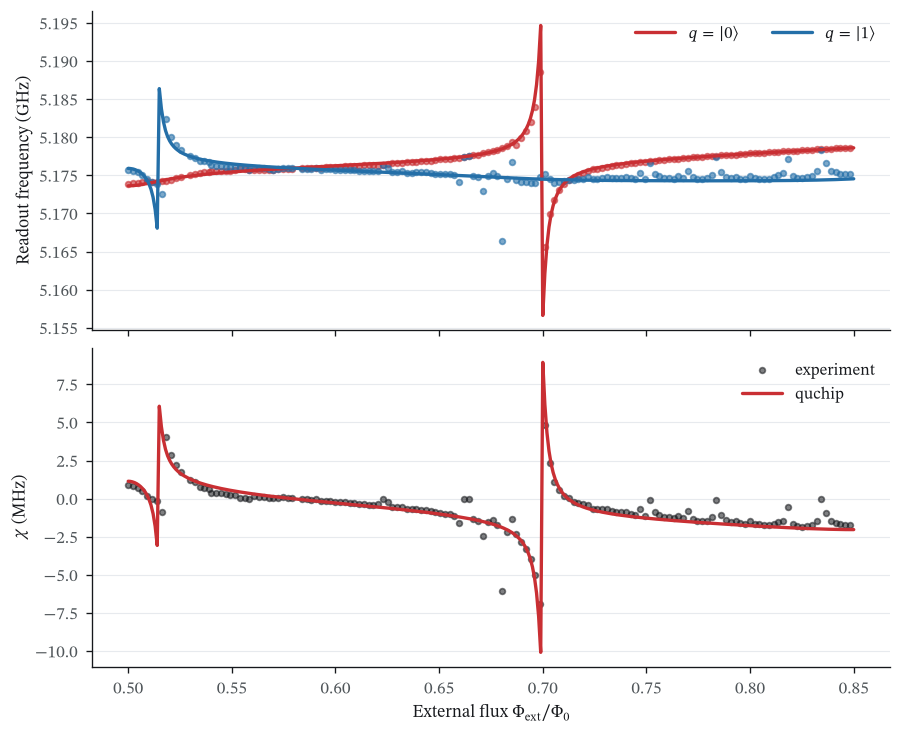

In [22]:
readout_figure, (frequency_axis, chi_axis) = plt.subplots(
    2,
    1,
    figsize=(7.4, 6.0),
    sharex=True,
    layout="constrained",
)
frequency_axis.scatter(readout_flux, measured_fr0, s=12, color="#C92F33", alpha=0.6)
frequency_axis.scatter(readout_flux, measured_fr1, s=12, color="#246FA8", alpha=0.6)
frequency_axis.plot(
    readout_model_flux,
    predicted_fr0_grid,
    color="#C92F33",
    label=r"$q=|0\rangle$",
)
frequency_axis.plot(
    readout_model_flux,
    predicted_fr1_grid,
    color="#246FA8",
    label=r"$q=|1\rangle$",
)
frequency_axis.set_ylabel("Readout frequency (GHz)")
frequency_axis.legend(ncols=2)

chi_axis.scatter(
    readout_flux,
    measured_chi_mhz,
    s=12,
    color="#16181C",
    alpha=0.55,
    label="experiment",
)
chi_axis.plot(
    readout_model_flux,
    predicted_chi_grid_mhz,
    color="#C92F33",
    linewidth=2.0,
    label="quchip",
)
chi_axis.set(
    xlabel=r"External flux $\Phi_{\mathrm{ext}}/\Phi_0$",
    ylabel=r"$\chi$ (MHz)",
)
chi_axis.legend()

paper_readout_path = "../docs/images/stefanski_fluxonium_readout.svg"
readout_figure.savefig(paper_readout_path)
plt.show()

</details>

```{figure} ../images/stefanski_fluxonium_readout.svg
:width: 720px
:alt: Measured and predicted state-dependent readout resonator frequencies and dispersive shift across external flux

The same chip reproduces the state-dependent readout frequencies and the
higher-level resonances in the dispersive shift.
```

The paper operates at the sweet spot for idle and control, then pulses to
$\Phi_{\mathrm{ext}}/\Phi_0=0.6567$ during readout. These two points give a
compact numerical check against the values quoted in the text.

In [23]:
sweet_spot = readout_observables(0.5)
flux_pulsed = readout_observables(0.6567)

operating_points = {
    "sweet_spot": {
        "paper_f01_ghz": 0.377,
        "quchip_f01_ghz": isolated_f01(0.5),
        "paper_fr0_ghz": 5.1739,
        "quchip_fr0_ghz": sweet_spot[0],
        "paper_chi_mhz": 0.92,
        "quchip_chi_mhz": sweet_spot[2],
    },
    "flux_pulsed_readout": {
        "paper_flux": 0.6567,
        "paper_f01_ghz": 3.47,
        "quchip_f01_ghz": isolated_f01(0.6567),
        "paper_chi_mhz": -1.09,
        "quchip_chi_mhz": flux_pulsed[2],
    },
}

operating_points

{'sweet_spot': {'paper_f01_ghz': 0.377,
  'quchip_f01_ghz': 0.37229583974984704,
  'paper_fr0_ghz': 5.1739,
  'quchip_fr0_ghz': 5.173631975636749,
  'paper_chi_mhz': 0.92,
  'quchip_chi_mhz': 1.141802995038077},
 'flux_pulsed_readout': {'paper_flux': 0.6567,
  'paper_f01_ghz': 3.47,
  'quchip_f01_ghz': 3.4802282134309697,
  'paper_chi_mhz': -1.09,
  'quchip_chi_mhz': -1.135184138343126}}

<details>
<summary>Numerical record</summary>

In [24]:
resonator_residual_mhz = 1.0e3 * np.concatenate(
    [predicted_fr0_at_data - measured_fr0, predicted_fr1_at_data - measured_fr1]
)
chi_residual_mhz = predicted_chi_at_data_mhz - measured_chi_mhz

paper_receipt = {
    "chi_median_absolute_error_mhz": float(np.median(np.abs(chi_residual_mhz))),
    "chi_rmse_mhz": float(np.sqrt(np.mean(chi_residual_mhz**2))),
    "readout_frequency_rmse_mhz": float(
        np.sqrt(np.mean(resonator_residual_mhz**2))
    ),
    "readout_points": len(readout_flux),
    "readout_model_points": len(readout_model_flux),
    "spectrum_median_absolute_error_mhz": spectrum_check["median_absolute_error_mhz"],
    "spectrum_p95_absolute_error_mhz": spectrum_check["p95_absolute_error_mhz"],
    "spectrum_points": len(paper_flux),
    "spectrum_model_points": len(paper_model_flux),
}

print(
    "RESULT paper_statics="
    + json.dumps(paper_receipt, sort_keys=True, separators=(",", ":"))
)

RESULT paper_statics={"chi_median_absolute_error_mhz":0.17674709860890925,"chi_rmse_mhz":0.7651558998067052,"readout_frequency_rmse_mhz":1.0847642735011205,"readout_model_points":351,"readout_points":151,"spectrum_median_absolute_error_mhz":1.5923938298039175,"spectrum_model_points":351,"spectrum_p95_absolute_error_mhz":6.076768528398682,"spectrum_points":153}


</details>

The paper's authors fitted the circuit parameters to these measurements.
Treat this result as a cross-implementation check of their static model. A
fabrication-level prediction would require independent circuit parameters.